In [2]:
import numpy as np
import netket as nk

from netket.graph.common_lattices import Chain
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

print('NetKet version:', nk.__version__)

C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: To build H|ψ⟩ use nk.vqs.apply_operator(H, vstate_ψ).

NetKet version: 3.21.1.dev13+gbf43effcb


In [3]:
L = 19  # 导带链长度（不含杂质）
chain = Chain(L, pbc=False)
N = chain.n_nodes   # 格点数量，后续会被应用为神经网络的优化参数数量

impurity_site = 0
conduction_offset = 1  # 导带链局部索引 i -> 全局站点 i+1
n_orbitals = L + 1  # 1 个杂质轨道 + L 个导带轨道

if n_orbitals % 2 != 0:
    raise ValueError("n_orbitals 必须为偶数，才能设置 N_up = N_dn = n_orbitals/2")

N_up = n_orbitals // 2
N_dn = n_orbitals // 2

# 在这里直接限制 Hilbert 空间粒子数
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals, s=1 / 2, n_fermions_per_spin=(N_up, N_dn)
 )

print('chain nodes =', chain.n_nodes, ', chain edges =', chain.n_edges)
print('n_orbitals =', n_orbitals)
print('fixed particles (N_up, N_dn) =', (N_up, N_dn))


U = 4.0
V = 0.15
ti = np.ones(L - 1)  # t_i: 导带链上相邻站点之间的 hopping, 长度 L-1

H = 0.0

# 杂质上的库仑相互作用: U (n_d↑ - 1/2)(n_d↓ - 1/2)
n_d_up = nc(hi, impurity_site, sz=+1)
n_d_dn = nc(hi, impurity_site, sz=-1)
H += U * (n_d_up - 0.5) @ (n_d_dn - 0.5)


# 杂质-导带首站点混成: V Σσ (d†σ c0σ + c0†σ dσ)
c0_site = conduction_offset
for sz in (+1, -1):
    H += V * (cdag(hi, impurity_site, sz=sz) @ c(hi, c0_site, sz=sz))
    H += V * (cdag(hi, c0_site, sz=sz) @ c(hi, impurity_site, sz=sz))

# 导带链 hopping: Σσ Σ_i t_i (c†_{iσ} c_{i-1,σ} + h.c.)
# 使用 Chain(L) 的边来确定一维最近邻，局部索引 (0..L-1) 需要偏移到全局站点 (1..L)。
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]

    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset

    for sz in (+1, -1):
        H += t_bond * (cdag(hi, right_site, sz=sz) @ c(hi, left_site, sz=sz))
        H += t_bond * (cdag(hi, left_site, sz=sz) @ c(hi, right_site, sz=sz))

H


chain nodes = 19 , chain edges = 18
n_orbitals = 20
fixed particles (N_up, N_dn) = (10, 10)


FermionOperator2ndJax(hilbert=SpinOrbitalFermions(n_orbitals=20, s=1/2, n_fermions=20, n_fermions_per_spin=(10, 10)), n_operators=80, dtype=float64)

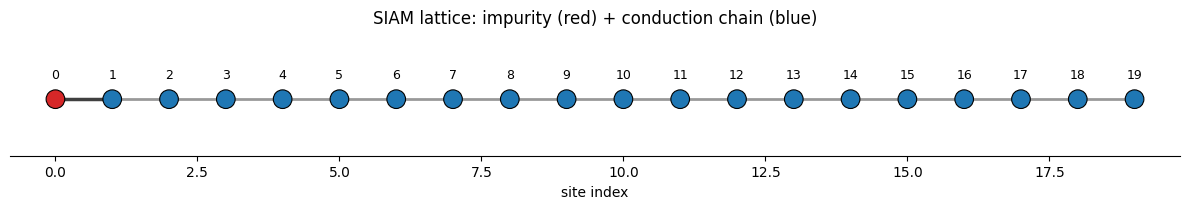

In [ ]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.2))

# 导带内部边（将 chain 的局部索引映射到全局站点 1..L）
for i_local, j_local in chain.edges():
    ax.plot(
        [i_local + conduction_offset, j_local + conduction_offset],
        [0, 0],
        color="0.6",
        lw=2,
        zorder=1,
    )

# 杂质-导带首站点混成边
ax.plot([impurity_site, c0_site], [0, 0], color="0.25", lw=2.5, zorder=2)

# 节点着色：杂质红色，其它导带蓝色
x = np.arange(n_orbitals)
y = np.zeros(n_orbitals)
node_colors = ["tab:red"] + ["tab:blue"] * L
ax.scatter(x, y, c=node_colors, s=180, edgecolors="black", linewidths=0.8, zorder=3)

for site in range(n_orbitals):
    ax.text(site, 0.08, str(site), ha="center", va="bottom", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("site index")
ax.set_title("SIAM lattice: impurity (red) + conduction chain (blue)")
ax.set_xlim(-0.8, n_orbitals - 0.2)
ax.set_ylim(-0.25, 0.3)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
from functools import partial

# ========= Reproducibility seeds =========
SEED_MODEL_SLATER = 11
SEED_SAMPLER_SLATER = 101
SEED_MODEL_NJ = 22
SEED_SAMPLER_NJ = 202
SEED_MODEL_BF = 33
SEED_SAMPLER_BF = 303

# 给采样器构造“空间轨道图”：杂质-首导带 + 导带链最近邻
sampler_edges = [(impurity_site, c0_site)]
sampler_edges += [
    (min(i, j) + conduction_offset, max(i, j) + conduction_offset)
    for (i, j) in chain.edges()
 ]
graph_sampler = nk.graph.Graph(edges=sampler_edges, n_nodes=n_orbitals)

# ==============================================================================
# 体系太大，已彻底移除 ED (Exact Diagonalization) 精确求解部分
# ==============================================================================
E_gs = None 

print("reference E_gs = Not Available (System too large for ED)")
print("sampler graph nodes/edges =", graph_sampler.n_nodes, graph_sampler.n_edges)
print(
    "seeds:",
    (SEED_MODEL_SLATER, SEED_SAMPLER_SLATER, SEED_MODEL_NJ, SEED_SAMPLER_NJ, SEED_MODEL_BF, SEED_SAMPLER_BF),
)

reference E_gs = Not Available (System too large for ED)
sampler graph nodes/edges = 20 19
seeds: (11, 101, 22, 202, 33, 303)


In [9]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk

print("=" * 70)
print(">>> [Cell 1] 定义高精度 LogNeuralJastrowSlater 拟设")
print("=" * 70)

class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32

    @nn.compact
    def __call__(self, n):
        # 1. 强制全局使用 float64，保证行列式求对数的数值稳定性
        dtype = jnp.float64

        # 2. Slater 行列式 (物理层：处理节点面和正负号)
        # 尽管 param_dtype 是实数，NetKet 底层遇到负行列式会自动安全提升为 complex128
        log_slater = nk.models.Slater2nd(
            self.hilbert, 
            generalized=False, 
            restricted=False, 
            param_dtype=dtype
        )(n)

        # 3. Neural Jastrow 因子 (关联层：处理 Hubbard U 和振幅压制)
        x = n.astype(dtype)
        # 第一层：提取轨道间的协同模式
        j = nn.Dense(self.hidden_units, param_dtype=dtype)(x)
        j = jax.nn.tanh(j)
        # 第二层：压缩为标量能量惩罚/奖励分值
        j = nn.Dense(1, param_dtype=dtype)(j).squeeze(-1)
        
        # 4. 终极组合：实数关联振幅 + 复数节点相位
        return log_slater + j

print("拟设类 LogNeuralJastrowSlater 编译完成！")

>>> [Cell 1] 定义高精度 LogNeuralJastrowSlater 拟设
拟设类 LogNeuralJastrowSlater 编译完成！


In [10]:
import optax
import netket as nk

print("=" * 70)
print(">>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR")
print("=" * 70)

# ==============================================================================
# 1. 初始化模型与采样器
# ==============================================================================
# 这里的 hi, graph_sampler, SEED_MODEL_NJ, SEED_SAMPLER_NJ 请确保在前文已定义
model_nj = LogNeuralJastrowSlater(hi, hidden_units=8)
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

# 保持 16384 的高采样率，对于 Jastrow 来说毫无压力
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**13,          
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,       
    sampler_seed=SEED_SAMPLER_NJ,
)

nj_p = vstate_nj.n_parameters
print(f" [NJ] Total Params: {nj_p} (参数量较小，QGT 矩阵极度健康)")

# ==============================================================================
# 2. 定制版外层优化器：Optax Adam
# ==============================================================================
lr_schedule_nj = optax.cosine_decay_schedule(
    init_value=0.02,   # 起步学习率，配合 SR 使用 0.02 是一个很稳的甜点位
    decay_steps=300, 
    alpha=0.01  
)

op_nj = optax.adam(
    learning_rate=lr_schedule_nj,
    b1=0.8,            # 【核心修改】：降低动量惯性，防止越过谷底后疯狂反弹 (Spikes)
    b2=0.999,          # 保持极高二阶矩，熨平 MCMC 的统计噪声
    eps=1e-8
)

# ==============================================================================
# 3. 驱动器：直接使用 VMC_SR 并开启物理加速
# ==============================================================================
gs_nj = nk.driver.VMC_SR(
    H, 
    op_nj, 
    variational_state=vstate_nj, 
    diag_shift=0.005,  # 小的对角线平移，增强数值稳定性
    mode="real"        # 【绝对核心】：砍掉无用的虚部计算，内存减半，单步速度飙升数倍！
)

# ==============================================================================
# 4. 运行优化与评估
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
print("开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...")
gs_nj.run(n_iter=200, out=nj_log)

E_nj = vstate_nj.expect(H)
print("-" * 70)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

# 如果你有精确基态能量 E_gs，可以取消下面的注释来计算相对误差
# err_nj = abs((E_nj.mean - E_gs) / E_gs)
# print(f"Relative error: {err_nj:.2e}")
print("=" * 70)

>>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR
 [NJ] Total Params: 737 (参数量较小，QGT 矩阵极度健康)
Automatic SR implementation choice:  QGT
开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...


100%|██████████| 200/200 [18:22<00:00,  5.51s/it, Energy=-24.421660+0.000000j ± 0.000095 [σ²=7.6e-05, R̂=1.001]]


----------------------------------------------------------------------
Neural Jastrow-Slater optimized energy: -24.421781+0.000000j ± 0.000088 [σ²=4.9e-05, R̂=1.001]


>>> [测量模块] 强关联升级版：分离 Spin-Up 与 Spin-Down 1-RDM (开启守恒加速)
已锁定 MCMC 样本，正在同时测算 Up 和 Down 轨道矩阵...
进度: 4 / 20 行已测算完成
进度: 8 / 20 行已测算完成
进度: 12 / 20 行已测算完成
进度: 16 / 20 行已测算完成
进度: 20 / 20 行已测算完成


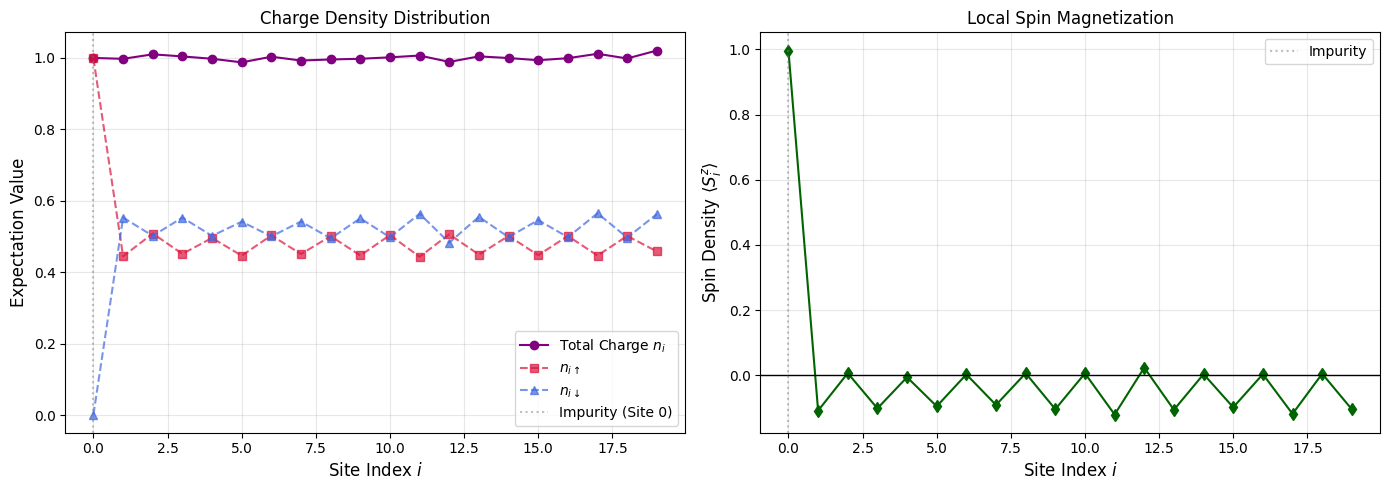

In [11]:
import numpy as np
import netket as nk
import netket.experimental as nkx  # 【新增】：导入实验性加速模块
import matplotlib.pyplot as plt

print("=" * 70)
print(">>> [测量模块] 强关联升级版：分离 Spin-Up 与 Spin-Down 1-RDM (开启守恒加速)")
print("=" * 70)

def compute_full_1rdm(vstate, n_sites):
    hilbert = vstate.hilbert
    rho_up = np.zeros((n_sites, n_sites), dtype=complex)
    rho_dn = np.zeros((n_sites, n_sites), dtype=complex)
    
    # 核心：锁定 MCMC 样本，保证 up 和 dn 的测量在同一批样本上进行，消除相对涨落
    _ = vstate.samples 
    print(f"已锁定 MCMC 样本，正在同时测算 Up 和 Down 轨道矩阵...")

    for i in range(n_sites):
        for j in range(n_sites):
            # 1. 构造 Spin-Up 算符: c^\dagger_{i,\uparrow} c_{j,\uparrow}
            term_up = (((i, 1), (j, 0)),)
            op_up_raw = nk.operator.FermionOperator2nd(hilbert, terms=term_up, dtype=float)
            # 【核心修改】：套上守恒外挂，切断无关希尔伯特空间的搜索
            op_up = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_up_raw)
            
            # 2. 构造 Spin-Down 算符: c^\dagger_{i,\downarrow} c_{j,\downarrow}
            term_dn = (((i + n_sites, 1), (j + n_sites, 0)),)
            op_dn_raw = nk.operator.FermionOperator2nd(hilbert, terms=term_dn, dtype=float)
            # 【核心修改】：套上守恒外挂
            op_dn = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_dn_raw)
            
            # 计算期望值 (此时底层计算量极小)
            rho_up[i, j] = vstate.expect(op_up).mean
            rho_dn[i, j] = vstate.expect(op_dn).mean
            
        if (i + 1) % 4 == 0:
            print(f"进度: {i + 1} / {n_sites} 行已测算完成")
            
    return rho_up, rho_dn

# 执行测量 (假设 n_sites = 20)
n_sites = 20
rho_up, rho_dn = compute_full_1rdm(vstate_nj, n_sites)

# ==============================================================================
# 物理量提取：电荷与自旋分离
# ==============================================================================
# 1. 提取实空间对角占据数
n_up = np.real(np.diag(rho_up))
n_dn = np.real(np.diag(rho_dn))

# 2. 计算总电荷密度 (Charge Density): <n_{i\uparrow}> + <n_{i\downarrow}>
charge_density = n_up + n_dn

# 3. 计算局域自旋磁矩 (Spin Density / Local Magnetization): <n_{i\uparrow}> - <n_{i\downarrow}>
spin_density = n_up - n_dn

# ==============================================================================
# 物理图像可视化
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 图 1: 电荷密度重分布 (Hubbard U 导致的排斥)
ax1.plot(range(n_sites), charge_density, 'o-', color='purple', label='Total Charge $n_i$')
ax1.plot(range(n_sites), n_up, 's--', color='crimson', alpha=0.7, label='$n_{i\\uparrow}$')
ax1.plot(range(n_sites), n_dn, '^--', color='royalblue', alpha=0.7, label='$n_{i\\downarrow}$')
ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Impurity (Site 0)')
ax1.set_xlabel('Site Index $i$', fontsize=12)
ax1.set_ylabel('Expectation Value', fontsize=12)
ax1.set_title('Charge Density Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# 图 2: 局域自旋极化 (Anderson/Kondo 物理的核心)
ax2.plot(range(n_sites), spin_density, 'd-', color='darkgreen', markersize=6)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Impurity')
ax2.set_xlabel('Site Index $i$', fontsize=12)
ax2.set_ylabel('Spin Density $\\langle S^z_i \\rangle$', fontsize=12)
ax2.set_title('Local Spin Magnetization')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
import optax
import netket as nk

print("=" * 70)
print(">>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR")
print("=" * 70)

# ==============================================================================
# 1. 初始化模型与采样器
# ==============================================================================
# 这里的 hi, graph_sampler, SEED_MODEL_NJ, SEED_SAMPLER_NJ 请确保在前文已定义
model_nj = LogNeuralJastrowSlater(hi, hidden_units=16)
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

# 保持 16384 的高采样率，对于 Jastrow 来说毫无压力
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**13,          
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,       
    sampler_seed=SEED_SAMPLER_NJ,
)

nj_p = vstate_nj.n_parameters
print(f" [NJ] Total Params: {nj_p} (参数量较小，QGT 矩阵极度健康)")

# ==============================================================================
# 2. 定制版外层优化器：Optax Adam
# ==============================================================================
lr_schedule_nj = optax.cosine_decay_schedule(
    init_value=0.02,   # 起步学习率，配合 SR 使用 0.02 是一个很稳的甜点位
    decay_steps=300, 
    alpha=0.01  
)

op_nj = optax.adam(
    learning_rate=lr_schedule_nj,
    b1=0.8,            # 【核心修改】：降低动量惯性，防止越过谷底后疯狂反弹 (Spikes)
    b2=0.999,          # 保持极高二阶矩，熨平 MCMC 的统计噪声
    eps=1e-8
)

# ==============================================================================
# 3. 驱动器：直接使用 VMC_SR 并开启物理加速
# ==============================================================================
gs_nj = nk.driver.VMC_SR(
    H, 
    op_nj, 
    variational_state=vstate_nj, 
    diag_shift=0.005,  # 小的对角线平移，增强数值稳定性
    mode="real"        # 【绝对核心】：砍掉无用的虚部计算，内存减半，单步速度飙升数倍！
)

# ==============================================================================
# 4. 运行优化与评估
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
print("开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...")
gs_nj.run(n_iter=200, out=nj_log)

E_nj = vstate_nj.expect(H)
print("-" * 70)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

# 如果你有精确基态能量 E_gs，可以取消下面的注释来计算相对误差
# err_nj = abs((E_nj.mean - E_gs) / E_gs)
# print(f"Relative error: {err_nj:.2e}")
print("=" * 70)

>>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR
 [NJ] Total Params: 1073 (参数量较小，QGT 矩阵极度健康)
Automatic SR implementation choice:  QGT
开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...


100%|██████████| 200/200 [14:22<00:00,  4.31s/it, Energy=-24.421768-0.000000j ± 0.000072 [σ²=3.8e-05, R̂=1.001]]


----------------------------------------------------------------------
Neural Jastrow-Slater optimized energy: -24.421748-0.000000j ± 0.000089 [σ²=6.3e-05, R̂=1.001]


>>> [测量模块] 强关联升级版：分离 Spin-Up 与 Spin-Down 1-RDM (开启守恒加速)
已锁定 MCMC 样本，正在同时测算 Up 和 Down 轨道矩阵...
进度: 4 / 20 行已测算完成
进度: 8 / 20 行已测算完成
进度: 12 / 20 行已测算完成
进度: 16 / 20 行已测算完成
进度: 20 / 20 行已测算完成


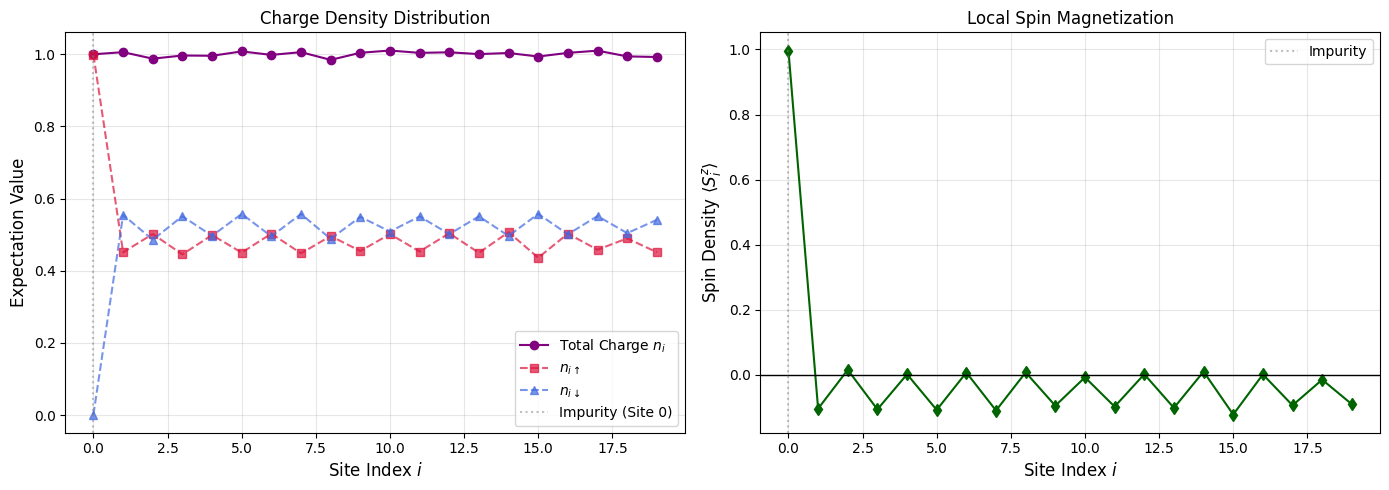

In [13]:
import numpy as np
import netket as nk
import netket.experimental as nkx  # 【新增】：导入实验性加速模块
import matplotlib.pyplot as plt

print("=" * 70)
print(">>> [测量模块] 强关联升级版：分离 Spin-Up 与 Spin-Down 1-RDM (开启守恒加速)")
print("=" * 70)

def compute_full_1rdm(vstate, n_sites):
    hilbert = vstate.hilbert
    rho_up = np.zeros((n_sites, n_sites), dtype=complex)
    rho_dn = np.zeros((n_sites, n_sites), dtype=complex)
    
    # 核心：锁定 MCMC 样本，保证 up 和 dn 的测量在同一批样本上进行，消除相对涨落
    _ = vstate.samples 
    print(f"已锁定 MCMC 样本，正在同时测算 Up 和 Down 轨道矩阵...")

    for i in range(n_sites):
        for j in range(n_sites):
            # 1. 构造 Spin-Up 算符: c^\dagger_{i,\uparrow} c_{j,\uparrow}
            term_up = (((i, 1), (j, 0)),)
            op_up_raw = nk.operator.FermionOperator2nd(hilbert, terms=term_up, dtype=float)
            # 【核心修改】：套上守恒外挂，切断无关希尔伯特空间的搜索
            op_up = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_up_raw)
            
            # 2. 构造 Spin-Down 算符: c^\dagger_{i,\downarrow} c_{j,\downarrow}
            term_dn = (((i + n_sites, 1), (j + n_sites, 0)),)
            op_dn_raw = nk.operator.FermionOperator2nd(hilbert, terms=term_dn, dtype=float)
            # 【核心修改】：套上守恒外挂
            op_dn = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_dn_raw)
            
            # 计算期望值 (此时底层计算量极小)
            rho_up[i, j] = vstate.expect(op_up).mean
            rho_dn[i, j] = vstate.expect(op_dn).mean
            
        if (i + 1) % 4 == 0:
            print(f"进度: {i + 1} / {n_sites} 行已测算完成")
            
    return rho_up, rho_dn

# 执行测量 (假设 n_sites = 20)
n_sites = 20
rho_up, rho_dn = compute_full_1rdm(vstate_nj, n_sites)

# ==============================================================================
# 物理量提取：电荷与自旋分离
# ==============================================================================
# 1. 提取实空间对角占据数
n_up = np.real(np.diag(rho_up))
n_dn = np.real(np.diag(rho_dn))

# 2. 计算总电荷密度 (Charge Density): <n_{i\uparrow}> + <n_{i\downarrow}>
charge_density = n_up + n_dn

# 3. 计算局域自旋磁矩 (Spin Density / Local Magnetization): <n_{i\uparrow}> - <n_{i\downarrow}>
spin_density = n_up - n_dn

# ==============================================================================
# 物理图像可视化
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 图 1: 电荷密度重分布 (Hubbard U 导致的排斥)
ax1.plot(range(n_sites), charge_density, 'o-', color='purple', label='Total Charge $n_i$')
ax1.plot(range(n_sites), n_up, 's--', color='crimson', alpha=0.7, label='$n_{i\\uparrow}$')
ax1.plot(range(n_sites), n_dn, '^--', color='royalblue', alpha=0.7, label='$n_{i\\downarrow}$')
ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Impurity (Site 0)')
ax1.set_xlabel('Site Index $i$', fontsize=12)
ax1.set_ylabel('Expectation Value', fontsize=12)
ax1.set_title('Charge Density Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# 图 2: 局域自旋极化 (Anderson/Kondo 物理的核心)
ax2.plot(range(n_sites), spin_density, 'd-', color='darkgreen', markersize=6)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Impurity')
ax2.set_xlabel('Site Index $i$', fontsize=12)
ax2.set_ylabel('Spin Density $\\langle S^z_i \\rangle$', fontsize=12)
ax2.set_title('Local Spin Magnetization')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
import optax
import netket as nk

print("=" * 70)
print(">>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR")
print("=" * 70)

# ==============================================================================
# 1. 初始化模型与采样器
# ==============================================================================
# 这里的 hi, graph_sampler, SEED_MODEL_NJ, SEED_SAMPLER_NJ 请确保在前文已定义
model_nj = LogNeuralJastrowSlater(hi, hidden_units=8)
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

# 保持 16384 的高采样率，对于 Jastrow 来说毫无压力
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**13,          
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,       
    sampler_seed=SEED_SAMPLER_NJ,
)

nj_p = vstate_nj.n_parameters
print(f" [NJ] Total Params: {nj_p} (参数量较小，QGT 矩阵极度健康)")

# ==============================================================================
# 2. 定制版外层优化器：Optax Adam
# ==============================================================================
lr_schedule_nj = optax.cosine_decay_schedule(
    init_value=0.02,   # 起步学习率，配合 SR 使用 0.02 是一个很稳的甜点位
    decay_steps=300, 
    alpha=0.01  
)

op_nj = optax.adam(
    learning_rate=lr_schedule_nj,
    b1=0.8,            # 【核心修改】：降低动量惯性，防止越过谷底后疯狂反弹 (Spikes)
    b2=0.999,          # 保持极高二阶矩，熨平 MCMC 的统计噪声
    eps=1e-8
)

# ==============================================================================
# 3. 驱动器：直接使用 VMC_SR 并开启物理加速
# ==============================================================================

# 【核心新增】：在传入驱动器之前，给哈密顿量加上 -0.1 * Sz 的 pinning field
h_pin = 0.1
# S^z_{imp} = 1/2 * (n_{d\uparrow} - n_{d\downarrow})
# H_{pin} = - h_{pin} * S^z_{imp} (强行打破简并，倾向于自旋向上)
# 假设 n_d_up 和 n_d_dn 在之前的 Cell 中已经定义好
H_pinned = H + h_pin * 0.5 * (n_d_up - n_d_dn)

gs_nj = nk.driver.VMC_SR(
    H_pinned,          # 【注意】：这里传入的是加上了外场的新哈密顿量
    op_nj, 
    variational_state=vstate_nj, 
    diag_shift=0.005,  # 小的对角线平移，增强数值稳定性
    mode="real"        # 【绝对核心】：砍掉无用的虚部计算，内存减半，单步速度飙升数倍！
)

# ==============================================================================
# 4. 运行优化与评估
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
print("开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...")
gs_nj.run(n_iter=200, out=nj_log)

# 【注意】：测量最终能量时，也需要用加上 pinning field 的 H_pinned
E_nj = vstate_nj.expect(H_pinned)
print("-" * 70)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

# 如果你有精确基态能量 E_gs，可以取消下面的注释来计算相对误差
# err_nj = abs((E_nj.mean - E_gs) / E_gs)
# print(f"Relative error: {err_nj:.2e}")
print("=" * 70)

>>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR
 [NJ] Total Params: 737 (参数量较小，QGT 矩阵极度健康)
Automatic SR implementation choice:  QGT
开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...


100%|██████████| 200/200 [08:16<00:00,  2.48s/it, Energy=-24.471601-0.000000j ± 0.000074 [σ²=4.2e-05, R̂=1.001]]


----------------------------------------------------------------------
Neural Jastrow-Slater optimized energy: -24.471502-0.000000j ± 0.000069 [σ²=3.7e-05, R̂=1.001]


>>> [测量模块] 强关联升级版：分离 Spin-Up 与 Spin-Down 1-RDM (开启守恒加速)
已锁定 MCMC 样本，正在同时测算 Up 和 Down 轨道矩阵...
进度: 4 / 20 行已测算完成
进度: 8 / 20 行已测算完成
进度: 12 / 20 行已测算完成
进度: 16 / 20 行已测算完成
进度: 20 / 20 行已测算完成


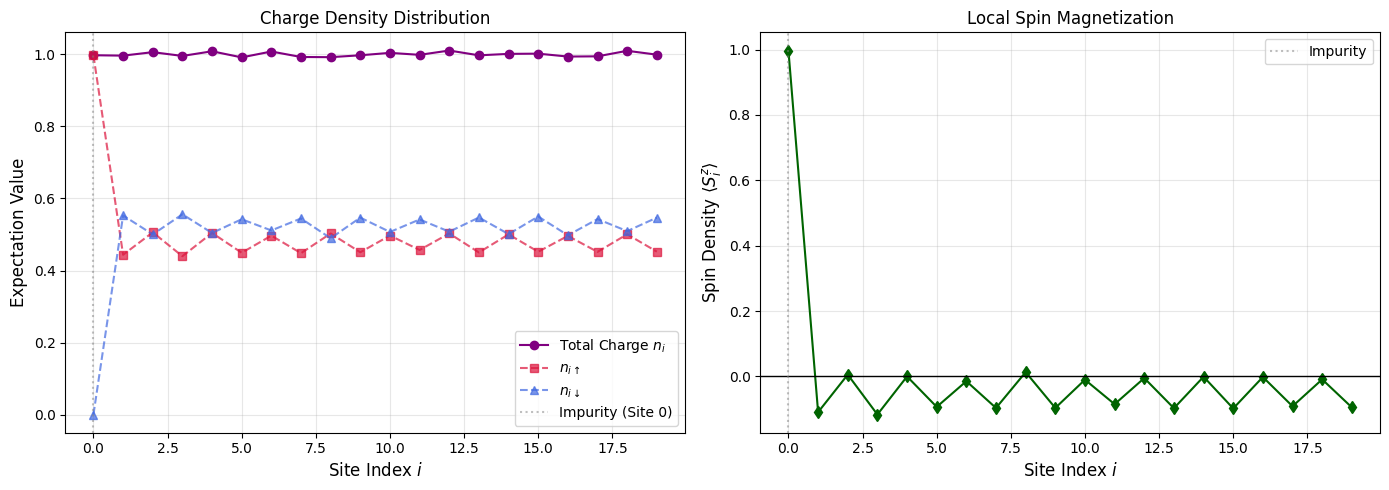

In [21]:
import numpy as np
import netket as nk
import netket.experimental as nkx  # 【新增】：导入实验性加速模块
import matplotlib.pyplot as plt

print("=" * 70)
print(">>> [测量模块] 强关联升级版：分离 Spin-Up 与 Spin-Down 1-RDM (开启守恒加速)")
print("=" * 70)

def compute_full_1rdm(vstate, n_sites):
    hilbert = vstate.hilbert
    rho_up = np.zeros((n_sites, n_sites), dtype=complex)
    rho_dn = np.zeros((n_sites, n_sites), dtype=complex)
    
    # 核心：锁定 MCMC 样本，保证 up 和 dn 的测量在同一批样本上进行，消除相对涨落
    _ = vstate.samples 
    print(f"已锁定 MCMC 样本，正在同时测算 Up 和 Down 轨道矩阵...")

    for i in range(n_sites):
        for j in range(n_sites):
            # 1. 构造 Spin-Up 算符: c^\dagger_{i,\uparrow} c_{j,\uparrow}
            term_up = (((i, 1), (j, 0)),)
            op_up_raw = nk.operator.FermionOperator2nd(hilbert, terms=term_up, dtype=float)
            # 【核心修改】：套上守恒外挂，切断无关希尔伯特空间的搜索
            op_up = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_up_raw)
            
            # 2. 构造 Spin-Down 算符: c^\dagger_{i,\downarrow} c_{j,\downarrow}
            term_dn = (((i + n_sites, 1), (j + n_sites, 0)),)
            op_dn_raw = nk.operator.FermionOperator2nd(hilbert, terms=term_dn, dtype=float)
            # 【核心修改】：套上守恒外挂
            op_dn = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_dn_raw)
            
            # 计算期望值 (此时底层计算量极小)
            rho_up[i, j] = vstate.expect(op_up).mean
            rho_dn[i, j] = vstate.expect(op_dn).mean
            
        if (i + 1) % 4 == 0:
            print(f"进度: {i + 1} / {n_sites} 行已测算完成")
            
    return rho_up, rho_dn

# 执行测量 (假设 n_sites = 20)
n_sites = 20
rho_up, rho_dn = compute_full_1rdm(vstate_nj, n_sites)

# ==============================================================================
# 物理量提取：电荷与自旋分离
# ==============================================================================
# 1. 提取实空间对角占据数
n_up = np.real(np.diag(rho_up))
n_dn = np.real(np.diag(rho_dn))

# 2. 计算总电荷密度 (Charge Density): <n_{i\uparrow}> + <n_{i\downarrow}>
charge_density = n_up + n_dn

# 3. 计算局域自旋磁矩 (Spin Density / Local Magnetization): <n_{i\uparrow}> - <n_{i\downarrow}>
spin_density = n_up - n_dn

# ==============================================================================
# 物理图像可视化
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 图 1: 电荷密度重分布 (Hubbard U 导致的排斥)
ax1.plot(range(n_sites), charge_density, 'o-', color='purple', label='Total Charge $n_i$')
ax1.plot(range(n_sites), n_up, 's--', color='crimson', alpha=0.7, label='$n_{i\\uparrow}$')
ax1.plot(range(n_sites), n_dn, '^--', color='royalblue', alpha=0.7, label='$n_{i\\downarrow}$')
ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Impurity (Site 0)')
ax1.set_xlabel('Site Index $i$', fontsize=12)
ax1.set_ylabel('Expectation Value', fontsize=12)
ax1.set_title('Charge Density Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# 图 2: 局域自旋极化 (Anderson/Kondo 物理的核心)
ax2.plot(range(n_sites), spin_density, 'd-', color='darkgreen', markersize=6)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Impurity')
ax2.set_xlabel('Site Index $i$', fontsize=12)
ax2.set_ylabel('Spin Density $\\langle S^z_i \\rangle$', fontsize=12)
ax2.set_title('Local Spin Magnetization')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:

# 【注意】：测量最终能量时，也需要用加上 pinning field 的 H_pinned
E_nj = vstate_nj.expect(H + h_pin * 0.5 * (n_d_up - n_d_dn))
print("-" * 70)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

----------------------------------------------------------------------
Neural Jastrow-Slater optimized energy: -24.471714+0.000000j ± 0.000098 [σ²=8.2e-05, R̂=1.001]


In [ ]:
gs_nj = nk.driver.VMC_SR(
    H,          # 【注意】：这里传入的是加上了外场的新哈密顿量
    op_nj, 
    variational_state=vstate_nj, 
    diag_shift=0.005,  # 小的对角线平移，增强数值稳定性
    mode="real"        # 【绝对核心】：砍掉无用的虚部计算，内存减半，单步速度飙升数倍！
)

# ==============================================================================
# 4. 运行优化与评估
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
print("开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...")
gs_nj.run(n_iter=200, out=nj_log)

# 【注意】：测量最终能量时，也需要用加上 pinning field 的 H_pinned
E_nj = vstate_nj.expect(H)
print("-" * 70)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")